In [128]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/saurabhshahane/fake-news-classification/WELFake_Dataset.csv


In [129]:
import pandas as pd

# Dataset path
file_path = "/kaggle/input/datasets/saurabhshahane/fake-news-classification/WELFake_Dataset.csv"

# Load dataset
df = pd.read_csv(file_path)

# Display first 5 rows
print(df.head())

# Shape
print("Shape:", df.shape)

# Column names
print(df.columns)

   Unnamed: 0                                              title  \
0           0  LAW ENFORCEMENT ON HIGH ALERT Following Threat...   
1           1                                                NaN   
2           2  UNBELIEVABLE! OBAMA’S ATTORNEY GENERAL SAYS MO...   
3           3  Bobby Jindal, raised Hindu, uses story of Chri...   
4           4  SATAN 2: Russia unvelis an image of its terrif...   

                                                text  label  
0  No comment is expected from Barack Obama Membe...      1  
1     Did they post their votes for Hillary already?      1  
2   Now, most of the demonstrators gathered last ...      1  
3  A dozen politically active pastors came here f...      0  
4  The RS-28 Sarmat missile, dubbed Satan 2, will...      1  
Shape: (72134, 4)
Index(['Unnamed: 0', 'title', 'text', 'label'], dtype='object')


In [130]:
print("Rows :", df.shape[0])
print("Columns :", df.shape[1])

Rows : 72134
Columns : 4


In [131]:
df.columns

Index(['Unnamed: 0', 'title', 'text', 'label'], dtype='object')

In [132]:
df

,Unnamed: 0,title,text,label
0,0,LAW ENFORCEMENT ON HIGH ALERT Following Threat...,No comment is expected from Barack Obama Membe...,1
1,1,NaN,Did they post their votes for Hillary already?,1
2,2,UNBELIEVABLE! OBAMA’S ATTORNEY GENERAL SAYS MO...,"Now, most of the demonstrators gathered last ...",1
3,3,"Bobby Jindal, raised Hindu, uses story of Chri...",A dozen politically active pastors came here f...,0
4,4,SATAN 2: Russia unvelis an image of its terrif...,"The RS-28 Sarmat missile, dubbed Satan 2, will...",1
...,...,...,...,...
72129,72129,Russians steal research on Trump in hack of U....,WASHINGTON (Reuters) - Hackers believed to be ...,0
72130,72130,WATCH: Giuliani Demands That Democrats Apolog...,"You know, because in fantasyland Republicans n...",1
72131,72131,Migrants Refuse To Leave Train At Refugee Camp...,Migrants Refuse To Leave Train At Refugee Camp...,0
72132,72132,Trump tussle gives unpopular Mexican leader mu...,MEXICO CITY (Reuters) - Donald Trump’s combati...,0


In [133]:
df['title'].head()

0    LAW ENFORCEMENT ON HIGH ALERT Following Threat...
1                                                  NaN
2    UNBELIEVABLE! OBAMA’S ATTORNEY GENERAL SAYS MO...
3    Bobby Jindal, raised Hindu, uses story of Chri...
4    SATAN 2: Russia unvelis an image of its terrif...
Name: title, dtype: object

In [134]:
df['text'].head()

0    No comment is expected from Barack Obama Membe...
1       Did they post their votes for Hillary already?
2     Now, most of the demonstrators gathered last ...
3    A dozen politically active pastors came here f...
4    The RS-28 Sarmat missile, dubbed Satan 2, will...
Name: text, dtype: object

# Label

In [135]:
df['label'].unique()

array([1, 0])

In [136]:
df['label'].value_counts()

label
1    37106
0    35028
Name: count, dtype: int64

In [137]:
(df['label'].value_counts(normalize=True))*100

label
1    51.440375
0    48.559625
Name: proportion, dtype: float64

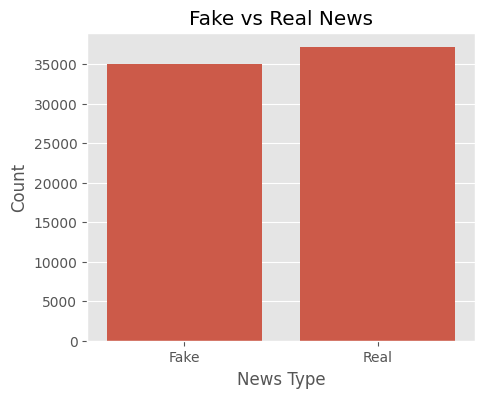

In [138]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(5, 4))
sns.countplot(x='label', data=df)

plt.xticks([0, 1], ['Fake', 'Real'])
plt.title("Fake vs Real News")
plt.xlabel("News Type")
plt.ylabel("Count")

plt.show()

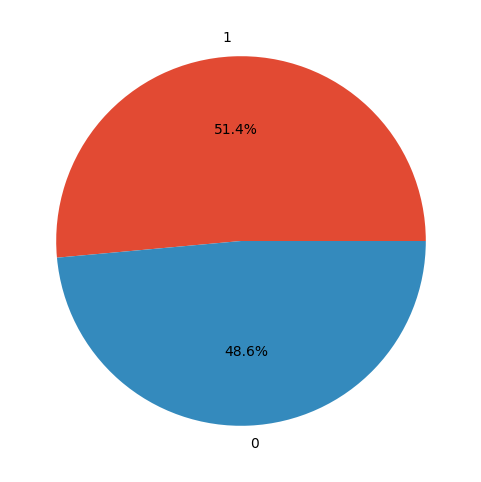

In [139]:
df['label'].value_counts().plot(
    kind='pie',
    autopct='%1.1f%%',
    figsize=(6,6)
)
plt.ylabel("")
plt.show()

# Text

In [140]:
df['text'].isnull().sum()

np.int64(39)

In [141]:
df['text'] = df['text'].fillna('')

df['text_length'] = df['text'].apply(len)

In [142]:
df['text_length']=df['text'].apply(len)
df['text_length'].head()

0    5049
1      46
2     216
3    8010
4    1916
Name: text_length, dtype: int64

# Title

In [143]:
df['title'].isnull().sum()

np.int64(558)

In [144]:
df = df.dropna(subset=['title'])

df['title_word_count'] = df['title'].str.split().str.len()

df[['title', 'title_word_count']].head()

/tmp/ipykernel_58/1859029923.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['title_word_count'] = df['title'].str.split().str.len()


,title,title_word_count
0,LAW ENFORCEMENT ON HIGH ALERT Following Threat...,18
2,UNBELIEVABLE! OBAMA’S ATTORNEY GENERAL SAYS MO...,18
3,"Bobby Jindal, raised Hindu, uses story of Chri...",16
4,SATAN 2: Russia unvelis an image of its terrif...,16
5,About Time! Christian Group Sues Amazon and SP...,13


In [145]:
df['word_count']=df['text'].apply(lambda x: len(x.split()))

/tmp/ipykernel_58/2445709872.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['word_count']=df['text'].apply(lambda x: len(x.split()))


In [146]:
df['word_count']

0         871
2          34
3        1321
4         329
5         244
         ... 
72129     735
72130     604
72131     477
72132     559
72133     448
Name: word_count, Length: 71576, dtype: int64

In [147]:
df['title_word_count']=df['title'].apply(lambda x: len(x.split()))

/tmp/ipykernel_58/159850383.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['title_word_count']=df['title'].apply(lambda x: len(x.split()))


In [148]:
df['title_word_count']

0        18
2        18
3        16
4        16
5        13
         ..
72129    11
72130    10
72131    10
72132    10
72133     7
Name: title_word_count, Length: 71576, dtype: int64

# Histogram of Text Length

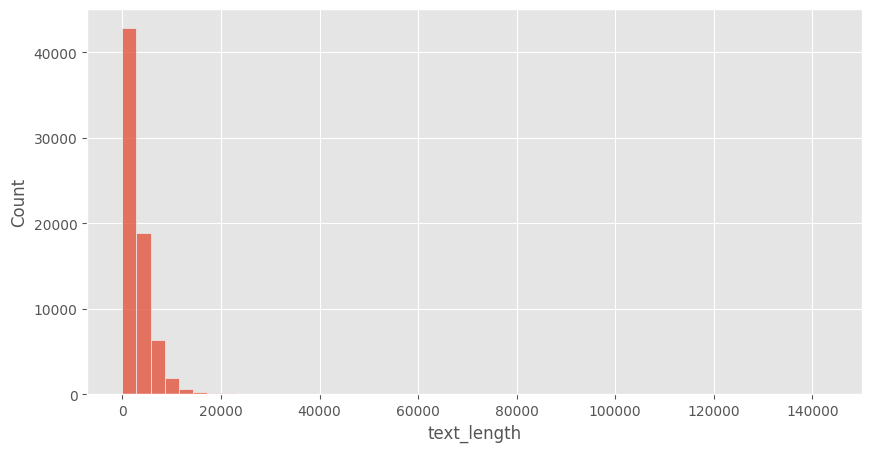

In [149]:
plt.figure(figsize=(10,5))
sns.histplot(df['text_length'],bins=50)
plt.show()

# Histogram of Word Count

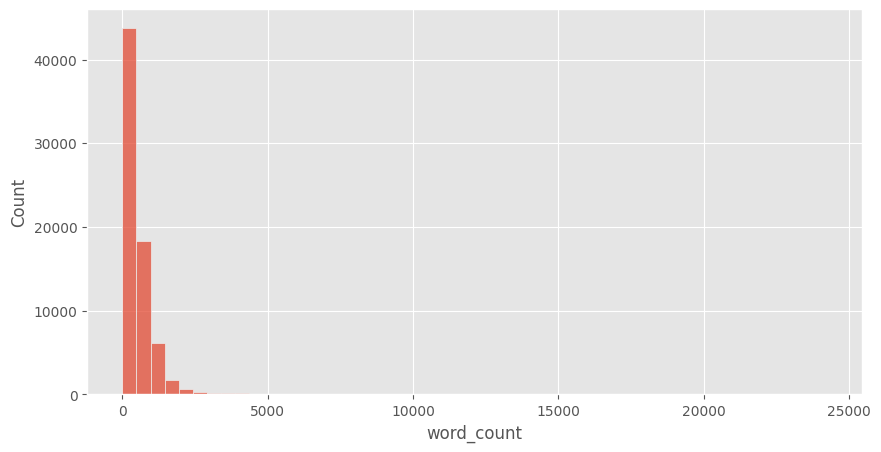

In [150]:
plt.figure(figsize=(10,5))
sns.histplot(df['word_count'],bins=50)
plt.show()

# Compare Fake vs Real Word Count

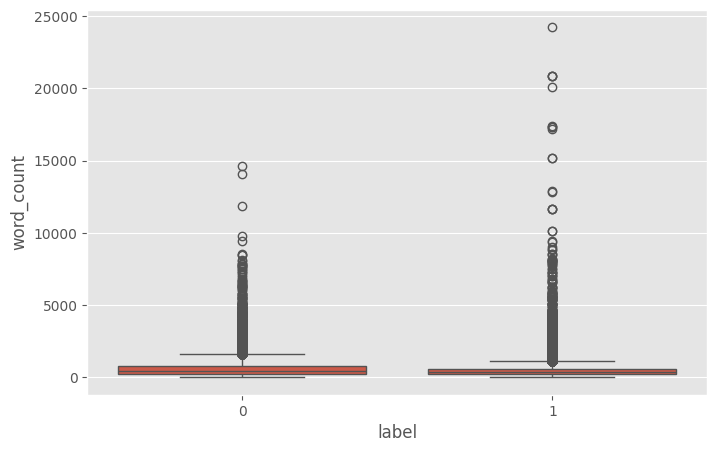

In [151]:
plt.figure(figsize=(8,5))
sns.boxplot(x='label',y='word_count',data=df)
plt.show()

# Compare Text Length

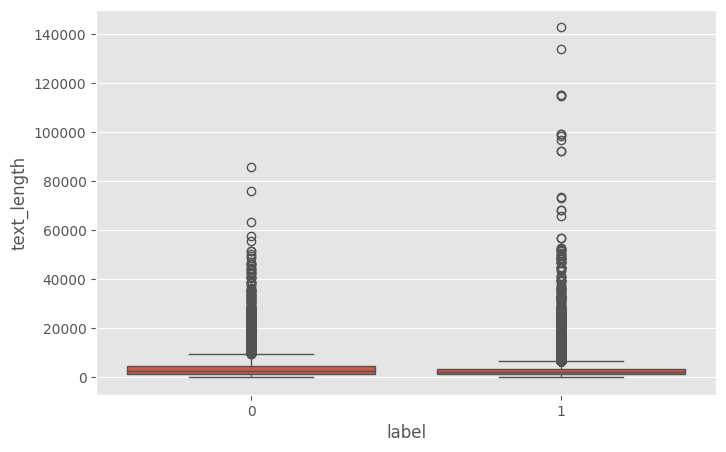

In [152]:
plt.figure(figsize=(8,5))
sns.boxplot(x='label',y='text_length',data=df)
plt.show()

# Longest News

In [153]:
df.loc[df['word_count'].idxmax()]

Unnamed: 0                                                        327
title               Re: The Hard Working American vs. The Governme...
text                The Hard Working American vs. The Government P...
label                                                               1
text_length                                                    134206
title_word_count                                                    9
word_count                                                      24234
Name: 327, dtype: object

# Shortest News

In [154]:
df.loc[df['word_count'].idxmin()]

Unnamed: 0                                                          7
title               HOUSE INTEL CHAIR On Trump-Russia Fake Story: ...
text                                                                 
label                                                               1
text_length                                                         1
title_word_count                                                   12
word_count                                                          0
Name: 7, dtype: object

# Correlation Matrix

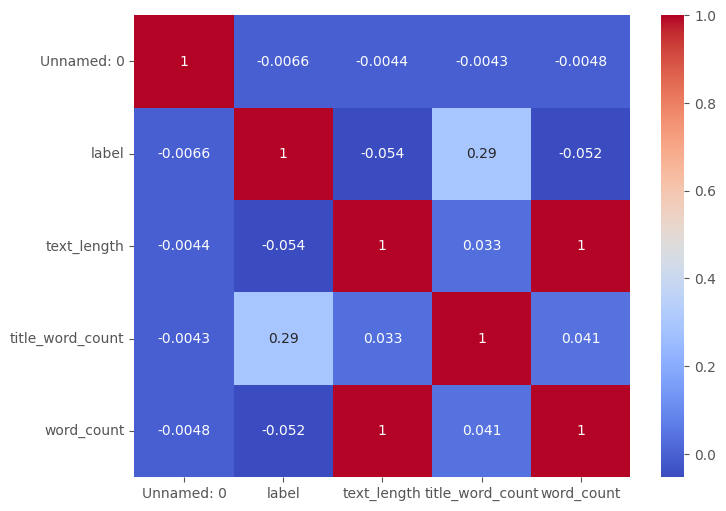

In [155]:
numeric=df.select_dtypes(include=np.number)

plt.figure(figsize=(8,6))
sns.heatmap(numeric.corr(),annot=True,cmap='coolwarm')
plt.show()

# Distribution Plot

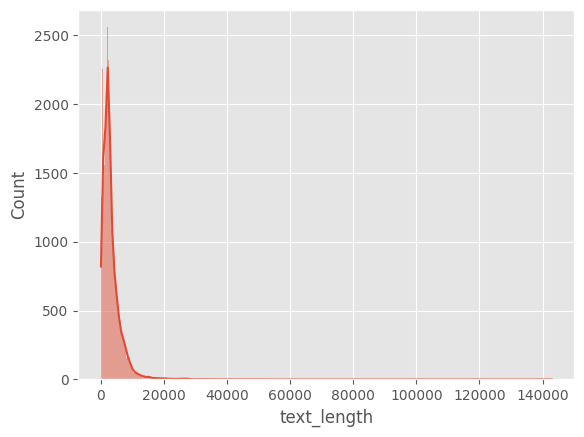

In [156]:
sns.histplot(df['text_length'],kde=True)
plt.show()

# KDE Plot

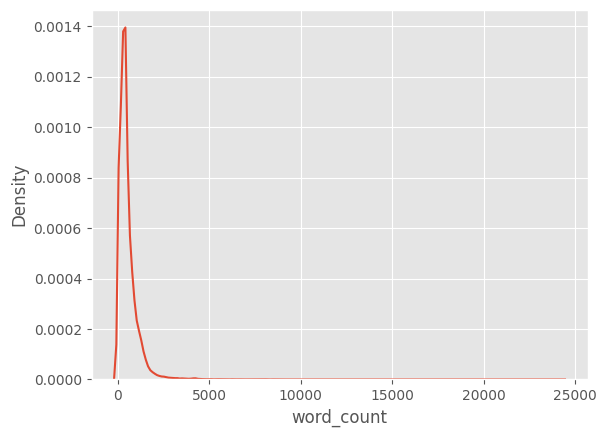

In [157]:
sns.kdeplot(df['word_count'])
plt.show()

# Scatter Plot

 # Most Frequent Words

In [158]:
from collections import Counter

words=" ".join(df['text']).split()

Counter(words).most_common(20)

[('the', 1979788),
 ('to', 1086681),
 ('of', 981647),
 ('and', 865833),
 ('a', 837087),
 ('in', 690634),
 ('that', 481933),
 ('is', 362884),
 ('for', 345947),
 ('on', 340700),
 ('was', 240922),
 ('with', 240873),
 ('as', 214798),
 ('The', 211148),
 ('he', 203451),
 ('by', 189091),
 ('it', 179773),
 ('his', 178419),
 ('have', 176270),
 ('be', 174646)]

# Word Cloud

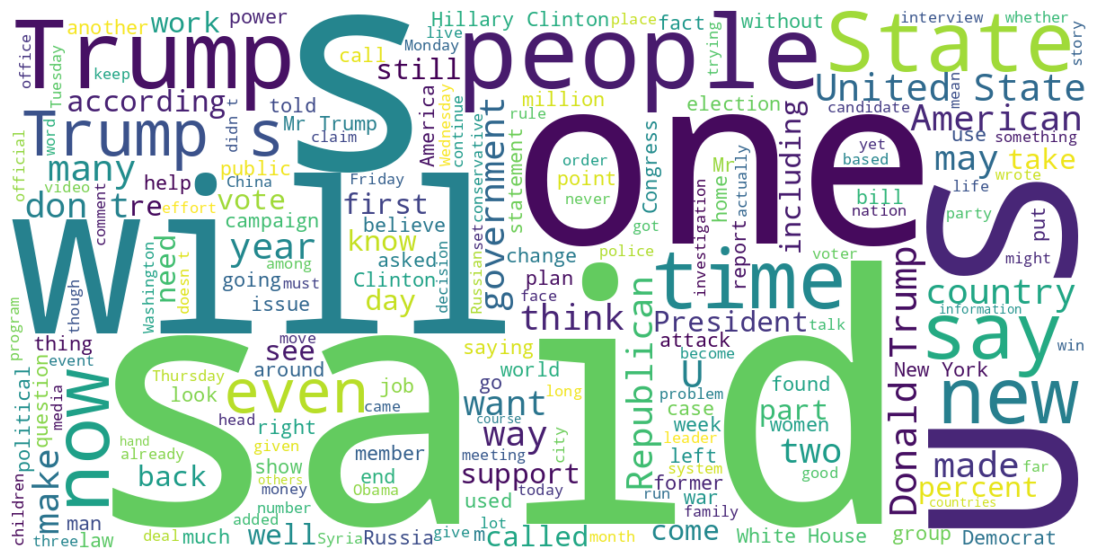

In [159]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

sample_text = " ".join(df['text'].sample(5000, random_state=42).astype(str))

wc = WordCloud(
    width=1200,
    height=600,
    background_color='white'
).generate(sample_text)

plt.figure(figsize=(15,7))
plt.imshow(wc, interpolation='bilinear')
plt.axis("off")
plt.show()

# Fake News Word Cloud

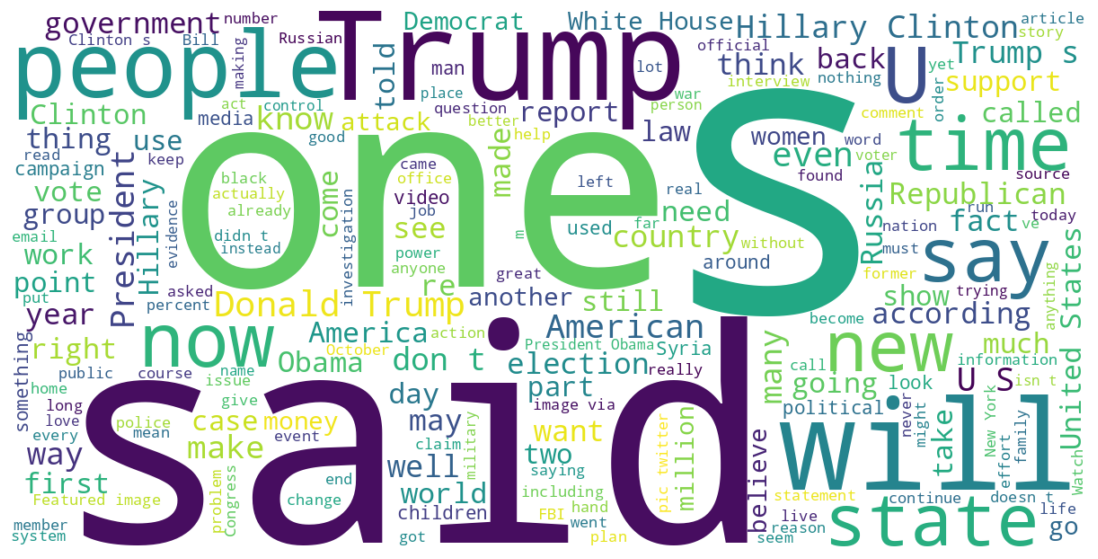

In [160]:
fake = " ".join(
    df[df['label'] == 1]['text']
      .dropna()
      .sample(3000, random_state=42)
      .astype(str)
)

wc = WordCloud(
    width=1200,
    height=600,
    background_color="white",
    max_words=200
).generate(fake)

plt.figure(figsize=(15,7))
plt.imshow(wc, interpolation="bilinear")
plt.axis("off")
plt.show()

# Real News Word Cloud

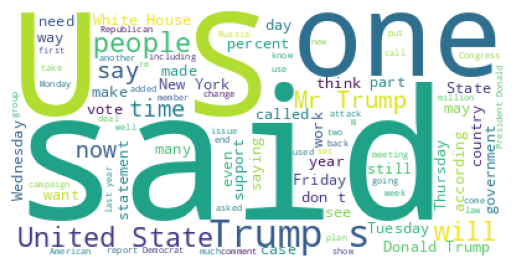

In [161]:
real=" ".join(df[df.label==0]['text'])

wc=WordCloud(
    background_color="white"
).generate(real)

plt.imshow(wc)
plt.axis("off")
plt.show()

# Most Common Words

In [162]:
from sklearn.feature_extraction.text import CountVectorizer

cv=CountVectorizer(stop_words='english',max_features=20)

X=cv.fit_transform(df['text'])

word_freq=pd.DataFrame(
    X.toarray(),
    columns=cv.get_feature_names_out()
)

word_freq.sum().sort_values(ascending=False)

said          234232
trump         213443
people         90303
president      90241
clinton        73925
mr             72378
new            70850
state          64162
like           56490
just           54578
obama          51531
states         50758
government     50248
time           49440
year           45600
house          44697
donald         42689
campaign       42481
united         42390
news           40078
dtype: int64

# Top 20 Words Plot

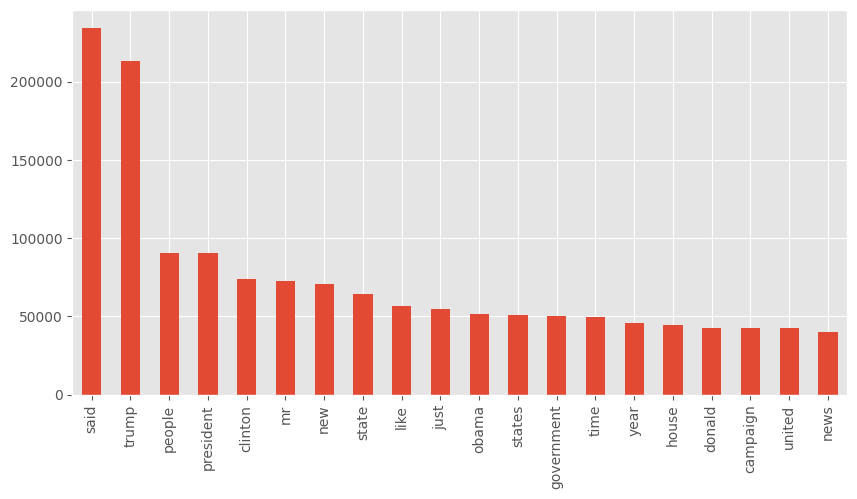

In [163]:
top=word_freq.sum().sort_values(ascending=False)

plt.figure(figsize=(10,5))
top.plot(kind='bar')
plt.show()

# Info

In [164]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 71576 entries, 0 to 72133
Data columns (total 7 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   Unnamed: 0        71576 non-null  int64 
 1   title             71576 non-null  object
 2   text              71576 non-null  object
 3   label             71576 non-null  int64 
 4   text_length       71576 non-null  int64 
 5   title_word_count  71576 non-null  int64 
 6   word_count        71576 non-null  int64 
dtypes: int64(5), object(2)
memory usage: 6.4+ MB


# Describe

In [165]:
df.describe()

,Unnamed: 0,label,text_length,title_word_count,word_count
count,71576.000000,71576.000000,71576.000000,71576.000000,71576.000000
mean,36046.041117,0.510618,3290.927993,12.268218,544.266095
std,20825.957650,0.499891,3737.965297,4.133661,626.299764
min,0.000000,0.000000,0.000000,1.000000,0.000000
25%,17999.750000,0.000000,1407.000000,9.000000,232.000000
50%,36037.500000,1.000000,2439.000000,12.000000,400.000000
75%,54083.250000,1.000000,4076.000000,14.000000,670.000000
max,72133.000000,1.000000,142961.000000,72.000000,24234.000000


# Finding NULL Values

In [166]:
df.isnull().mean()

Unnamed: 0          0.0
title               0.0
text                0.0
label               0.0
text_length         0.0
title_word_count    0.0
word_count          0.0
dtype: float64

In [167]:
(df.isnull().sum()/len(df))*100

Unnamed: 0          0.0
title               0.0
text                0.0
label               0.0
text_length         0.0
title_word_count    0.0
word_count          0.0
dtype: float64

# Step 1: Remove Unnamed: 0

In [168]:
df.isnull().sum()

Unnamed: 0          0
title               0
text                0
label               0
text_length         0
title_word_count    0
word_count          0
dtype: int64

In [169]:
# Remove unnecessary column
df.drop(columns=["Unnamed: 0"], inplace=True)

# Remove rows with missing title/text
df.dropna(inplace=True)

# Check
print(df.isnull().sum())
print(df.shape)

title               0
text                0
label               0
text_length         0
title_word_count    0
word_count          0
dtype: int64
(71576, 6)


/tmp/ipykernel_58/3777056866.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df.drop(columns=["Unnamed: 0"], inplace=True)
/tmp/ipykernel_58/3777056866.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df.dropna(inplace=True)


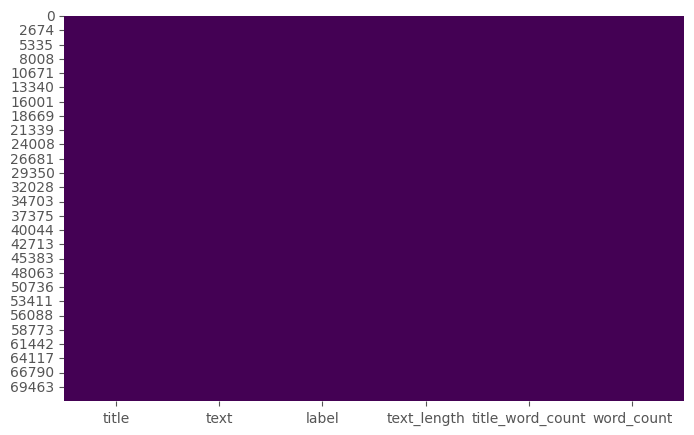

In [170]:
plt.figure(figsize=(8,5))
sns.heatmap(df.isnull(),cbar=False,cmap='viridis')
plt.show()

# Check Empty Titles

In [171]:
df['title'].isnull().sum()

np.int64(0)

# . Check Empty Text

In [172]:
df['text'].isnull().sum()

np.int64(0)

In [173]:
df.duplicated().sum()

np.int64(8416)

In [174]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("ggplot")

# Text Preprocessing

In [175]:
import re
import string
import nltk

from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

In [176]:
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('omw-1.4')

[nltk_data] Downloading package stopwords to /usr/share/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /usr/share/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to /usr/share/nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


True

In [177]:
stop_words = set(stopwords.words('english'))

lemmatizer = WordNetLemmatizer()

In [178]:
df["content"] = df["title"] + " " + df["text"]

/tmp/ipykernel_58/294308970.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["content"] = df["title"] + " " + df["text"]


# Create Preprocessing Function

In [179]:
def preprocess_text(text):

    # Convert to string
    text = str(text)

    # Lowercase
    text = text.lower()

    # Remove HTML tags
    text = re.sub(r'<.*?>', '', text)

    # Remove URLs
    text = re.sub(r'http\S+|www\S+', '', text)

    # Remove numbers
    text = re.sub(r'\d+', '', text)

    # Remove punctuation
    text = text.translate(str.maketrans('', '', string.punctuation))

    # Remove special characters
    text = re.sub(r'[^a-zA-Z\s]', '', text)

    # Remove extra spaces
    text = re.sub(r'\s+', ' ', text).strip()

    # Tokenize
    words = text.split()

    # Remove stopwords
    words = [word for word in words if word not in stop_words]

    # Lemmatization
    words = [lemmatizer.lemmatize(word) for word in words]

    return " ".join(words)

In [180]:
df["clean_text"] = df["content"].apply(preprocess_text)

/tmp/ipykernel_58/3421556082.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["clean_text"] = df["content"].apply(preprocess_text)


In [181]:
df['content']

0        LAW ENFORCEMENT ON HIGH ALERT Following Threat...
2        UNBELIEVABLE! OBAMA’S ATTORNEY GENERAL SAYS MO...
3        Bobby Jindal, raised Hindu, uses story of Chri...
4        SATAN 2: Russia unvelis an image of its terrif...
5        About Time! Christian Group Sues Amazon and SP...
                               ...                        
72129    Russians steal research on Trump in hack of U....
72130     WATCH: Giuliani Demands That Democrats Apolog...
72131    Migrants Refuse To Leave Train At Refugee Camp...
72132    Trump tussle gives unpopular Mexican leader mu...
72133    Goldman Sachs Endorses Hillary Clinton For Pre...
Name: content, Length: 71576, dtype: object

In [182]:
df[["content","clean_text"]].head()

,content,clean_text
0,LAW ENFORCEMENT ON HIGH ALERT Following Threat...,law enforcement high alert following threat co...
2,UNBELIEVABLE! OBAMA’S ATTORNEY GENERAL SAYS MO...,unbelievable obamas attorney general say charl...
3,"Bobby Jindal, raised Hindu, uses story of Chri...",bobby jindal raised hindu us story christian c...
4,SATAN 2: Russia unvelis an image of its terrif...,satan russia unvelis image terrifying new supe...
5,About Time! Christian Group Sues Amazon and SP...,time christian group sue amazon splc designati...


# Check Empty Documents

In [183]:
(df["clean_text"]=="").sum()

np.int64(53)

# Word Count Before and After

In [184]:
df["content"].str.split().str.len().describe()

count    71576.000000
mean       556.534313
std        626.483090
min          2.000000
25%        244.000000
50%        412.000000
75%        682.000000
max      24243.000000
Name: content, dtype: float64

In [185]:
df["clean_text"].str.split().str.len().describe()

count    71576.000000
mean       312.211146
std        337.806885
min          0.000000
25%        139.000000
50%        234.000000
75%        386.000000
max      12133.000000
Name: clean_text, dtype: float64

In [186]:
df.to_csv("fake_news_clean.csv", index=False)

In [187]:
X = df["clean_text"]

y = df["label"]

In [188]:
print(X.head())
print(y.head())

0    law enforcement high alert following threat co...
2    unbelievable obamas attorney general say charl...
3    bobby jindal raised hindu us story christian c...
4    satan russia unvelis image terrifying new supe...
5    time christian group sue amazon splc designati...
Name: clean_text, dtype: object
0    1
2    1
3    0
4    1
5    1
Name: label, dtype: int64


# TF-IDF Vectorization

In [189]:
from sklearn.feature_extraction.text import TfidfVectorizer
tfidf = TfidfVectorizer(
    max_features=10000,
    stop_words="english"
)
X = tfidf.fit_transform(X)
print(X.shape)

(71576, 10000)


# Convert Sparse Matrix to Dense

In [190]:
X = X.toarray()
print(type(X))
print(X.shape)

<class 'numpy.ndarray'>
(71576, 10000)


# Train-Test Split

In [191]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)
print(X_train.shape)
print(X_test.shape)

print(y_train.shape)
print(y_test.shape)

(57260, 10000)
(14316, 10000)
(57260,)
(14316,)


In [192]:
X_train = X_train.astype("float32")
X_test = X_test.astype("float32")

# Build ANN

In [193]:
import tensorflow as tf

from tensorflow.keras.models import Sequential

from tensorflow.keras.layers import Dense
from tensorflow.keras.layers import Dropout

In [194]:
model = Sequential()
model.add(Dense(
    512,
    activation="relu",
    input_shape=(X_train.shape[1],)
))
model.add(Dropout(0.3))

model.add(Dense(
    256,
    activation="relu"
))
model.add(Dropout(0.3))

model.add(Dense(
    128,
    activation="relu"
))
model.add(Dense(
    1,
    activation="sigmoid"
))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
I0000 00:00:1784459450.662433      58 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13756 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1784459450.665538      58 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13756 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


In [195]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 512)            │     5,120,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5,284,865 (20.16 MB)

 Trainable params: 5,284,865 (20.16 MB)

 Non-trainable params: 0 (0.00 B)

In [196]:
model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

# Train Model

In [197]:
history = model.fit(
    X_train,
    y_train,
    epochs=10,
    batch_size=32,
    validation_split=0.2
)

Epoch 1/10
  46/1432 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.6356 - loss: 0.6352

I0000 00:00:1784459460.077982     292 device_compiler.h:196] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


1432/1432 ━━━━━━━━━━━━━━━━━━━━ 13s 6ms/step - accuracy: 0.9316 - loss: 0.1723 - val_accuracy: 0.9563 - val_loss: 0.1211
Epoch 2/10
1432/1432 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9778 - loss: 0.0633 - val_accuracy: 0.9580 - val_loss: 0.1212
Epoch 3/10
1432/1432 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9935 - loss: 0.0200 - val_accuracy: 0.9584 - val_loss: 0.1424
Epoch 4/10
1432/1432 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9971 - loss: 0.0094 - val_accuracy: 0.9593 - val_loss: 0.1755
Epoch 5/10
1432/1432 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9982 - loss: 0.0058 - val_accuracy: 0.9600 - val_loss: 0.2050
Epoch 6/10
1432/1432 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9982 - loss: 0.0055 - val_accuracy: 0.9600 - val_loss: 0.2274
Epoch 7/10
1432/1432 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9991 - loss: 0.0032 - val_accuracy: 0.9529 - val_loss: 0.2840
Epoch 8/10
1432/1432 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9990 - loss: 0.0035 - val_accura

In [198]:
loss, accuracy = model.evaluate(
    X_test,
    y_test
)

print("Loss :", loss)

print("Accuracy :", accuracy)

448/448 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9576 - loss: 0.2776
Loss : 0.27760106325149536
Accuracy : 0.9575998783111572


In [199]:
pred = model.predict(X_test)
pred = (pred > 0.5).astype(int)

448/448 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


# Confusion Matrix

[[6680  326]
 [ 281 7029]]


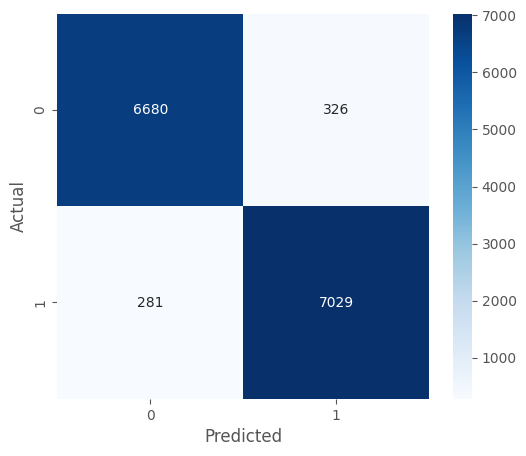

In [200]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(
    y_test,
    pred
)

print(cm)
plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.show()

# Accuracy Score

In [201]:
from sklearn.metrics import classification_report

print(
    classification_report(
        y_test,
        pred
    )
)

              precision    recall  f1-score   support

           0       0.96      0.95      0.96      7006
           1       0.96      0.96      0.96      7310

    accuracy                           0.96     14316
   macro avg       0.96      0.96      0.96     14316
weighted avg       0.96      0.96      0.96     14316



# ROC Curve

448/448 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


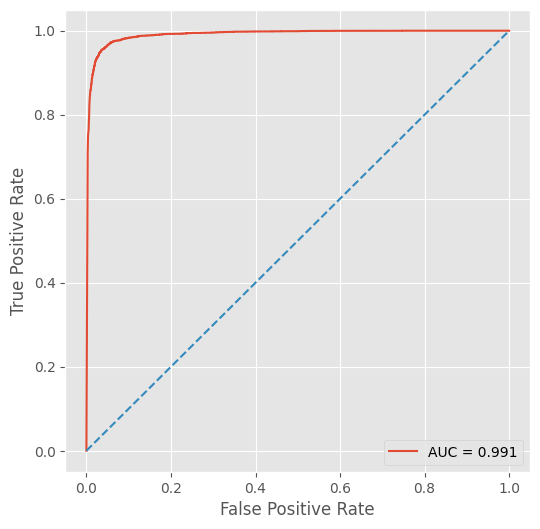

In [202]:
from sklearn.metrics import accuracy_score

accuracy_score(
    y_test,
    pred
)
from sklearn.metrics import roc_curve, auc

prob = model.predict(X_test)

fpr, tpr, threshold = roc_curve(
    y_test,
    prob
)

roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6,6))

plt.plot(
    fpr,
    tpr,
    label="AUC = %.3f" % roc_auc
)

plt.plot(
    [0,1],
    [0,1],
    linestyle="--"
)

plt.xlabel("False Positive Rate")

plt.ylabel("True Positive Rate")

plt.legend()

plt.show()

# Training Graph

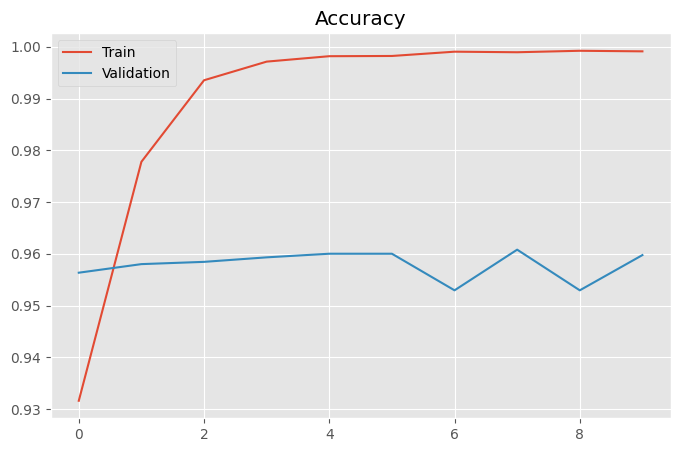

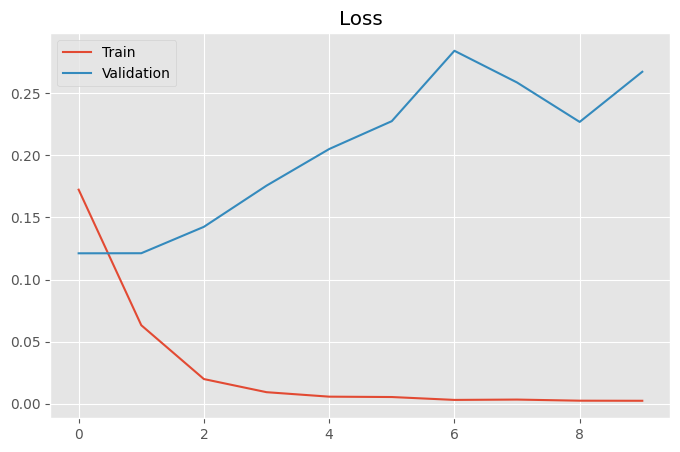

In [203]:
plt.figure(figsize=(8,5))

plt.plot(history.history["accuracy"])

plt.plot(history.history["val_accuracy"])

plt.legend(["Train","Validation"])

plt.title("Accuracy")

plt.show()

plt.figure(figsize=(8,5))

plt.plot(history.history["loss"])

plt.plot(history.history["val_loss"])

plt.legend(["Train","Validation"])

plt.title("Loss")

plt.show()

# Prediction Function

In [207]:
def predict_news(title, text):

    content = title + " " + text

    clean = preprocess_text(content)

    vector = tfidf.transform([clean]).toarray().astype("float32")

    prob = model.predict(vector, verbose=0)[0][0]

    if prob >= 0.5:
        print("Prediction : Fake News")
        print(f"Confidence : {prob*100:.2f}%")
    else:
        print("Prediction : Real News")
        print(f"Confidence : {(1-prob)*100:.2f}%")

In [210]:
title = "Federal Reserve keeps interest rates unchanged"

text = """
The Federal Reserve announced on Wednesday that it would keep
interest rates unchanged while continuing to monitor inflation
and labor market conditions.
"""

predict_news(title, text)

Prediction : Real News
Confidence : 99.60%


In [211]:
title = "Aliens elected as US President"

text = """
Secret government documents reveal that aliens have been elected
as the new President of the United States.
"""

predict_news(title, text)

Prediction : Fake News
Confidence : 99.99%


In [212]:
model.save("fake_news_ann.keras")

In [213]:
import pickle

with open("tfidf.pkl", "wb") as f:
    pickle.dump(tfidf, f)